In [3]:
print("Notebook is working")

Notebook is working


# Iris Classification using Spark MLlib

This project performs a classification task on the Iris dataset using Spark MLlib in PySpark.

The main objective is to predict Iris flower species based on sepal and petal measurements.

Three classification models are implemented:

1. Decision Tree
2. Random Forest
3. Logistic Regression

The workflow includes:

- Data loading
- Exploratory data analysis
- Input validation
- Data preprocessing
- Train-test split
- Model training
- Hyperparameter tuning
- Cross-validation
- Model evaluation
- Confusion matrix analysis
- Misclassification analysis
- Feature importance analysis
- Per-class analysis
- Model saving
- Comparative analysis
- Conclusion

# 1. Import Libraries

This section imports all required libraries for Spark processing, machine learning, model evaluation, visualisation, file handling, timing, and project configuration.

In [6]:
# ============================================================
# Import Libraries
# ============================================================

# Spark session
from pyspark.sql import SparkSession

# Spark ML pipeline and feature tools
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer

# Spark MLlib classification models
from pyspark.ml.classification import (
    DecisionTreeClassifier,
    RandomForestClassifier,
    LogisticRegression
)

# Model evaluation and tuning
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder

# Dataset and evaluation utilities
from sklearn.datasets import load_iris
from sklearn.metrics import confusion_matrix

# General libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import time
import shutil

# Allow notebook to read config.py from parent folder
sys.path.append("..")

# Import project configuration
from config import *

# 2. Create Required Folders

The data and output folders are created automatically if they do not already exist. This helps ensure that saved datasets, results, plots, and models can be stored properly.

In [7]:
# ============================================================
# Create Required Folders
# ============================================================

os.makedirs(DATA_PATH, exist_ok=True)
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Data and output folders are ready.")

Data and output folders are ready.


# 3. Start Spark Session

A SparkSession is created as the main entry point for using Spark DataFrames and Spark MLlib.

In [8]:
# ============================================================
# Start Spark Session
# ============================================================

spark = SparkSession.builder \
    .appName("Iris Classification using Spark MLlib") \
    .getOrCreate()

spark

# 4. Load Iris Dataset

The Iris dataset is loaded from scikit-learn. It is first converted into a pandas DataFrame, then saved as a CSV file, and finally converted into a Spark DataFrame for Spark MLlib processing.

In [9]:
# ============================================================
# Load Iris Dataset
# ============================================================

iris = load_iris()

iris_pdf = pd.DataFrame(
    iris.data,
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

# Convert NumPy string type into normal Python string
iris_pdf["species"] = [str(iris.target_names[i]) for i in iris.target]

# Save dataset using configured data path
iris_pdf.to_csv(f"{DATA_PATH}iris.csv", index=False)

# Convert pandas DataFrame into Spark DataFrame
df = spark.createDataFrame(iris_pdf)

# Display data
df.show(10)

# Display schema
df.printSchema()

+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2| setosa|
|         4.9|        3.0|         1.4|        0.2| setosa|
|         4.7|        3.2|         1.3|        0.2| setosa|
|         4.6|        3.1|         1.5|        0.2| setosa|
|         5.0|        3.6|         1.4|        0.2| setosa|
|         5.4|        3.9|         1.7|        0.4| setosa|
|         4.6|        3.4|         1.4|        0.3| setosa|
|         5.0|        3.4|         1.5|        0.2| setosa|
|         4.4|        2.9|         1.4|        0.2| setosa|
|         4.9|        3.1|         1.5|        0.1| setosa|
+------------+-----------+------------+-----------+-------+
only showing top 10 rows
root
 |-- sepal_length: double (nullable = true)
 |-- sepal_width: double (nullable = true)
 |-- petal_length: double (nullable = true)

## Dataset Insights

The first ten records show observations belonging to the **setosa** species, with measurements recorded for sepal length, sepal width, petal length, and petal width. These four numerical variables serve as the predictor features used to classify Iris flower species.

The dataset schema confirms that all four measurement variables are stored as **double** data types, making them suitable for machine learning algorithms that require numerical input. The target variable, **species**, is stored as a string and will later be converted into a numerical label during preprocessing using Spark MLlib's `StringIndexer`.

No missing values are visible in the sample records, and the schema indicates that the dataset structure is clean and consistent. This reduces the need for extensive data cleaning and allows the analysis to focus on feature relationships and model performance.

The sample observations suggest that petal measurements are relatively small for the setosa species. Previous studies of the Iris dataset have shown that petal characteristics are often the most important features for distinguishing between species. This relationship will be further explored during the exploratory data analysis stage and later validated through feature importance analysis.

Overall, the dataset appears well-structured, complete, and suitable for supervised classification using Spark MLlib.


# 5. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand the dataset structure, feature distribution, and class balance before model training.

In [10]:
# ============================================================
# Exploratory Data Analysis
# ============================================================

# Summary statistics
df.describe().show()

# Species count
df.groupBy("species").count().show()

# Convert Spark DataFrame into pandas DataFrame for plotting
eda_pdf = df.toPandas()

# Display first few rows
eda_pdf.head()

+-------+------------------+-------------------+------------------+------------------+---------+
|summary|      sepal_length|        sepal_width|      petal_length|       petal_width|  species|
+-------+------------------+-------------------+------------------+------------------+---------+
|  count|               150|                150|               150|               150|      150|
|   mean| 5.843333333333334| 3.0573333333333332|3.7580000000000005|1.1993333333333334|     NULL|
| stddev|0.8280661279778629|0.43586628493669816|1.7652982332594667|0.7622376689603465|     NULL|
|    min|               4.3|                2.0|               1.0|               0.1|   setosa|
|    max|               7.9|                4.4|               6.9|               2.5|virginica|
+-------+------------------+-------------------+------------------+------------------+---------+

+----------+-----+
|   species|count|
+----------+-----+
|    setosa|   50|
|versicolor|   50|
| virginica|   50|
+----------+

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Exploratory Data Analysis Insights

The summary statistics show that the Iris dataset contains **150 observations** with four numerical features: sepal length, sepal width, petal length, and petal width. All variables contain 150 records, indicating that there are no missing values in the dataset. This confirms that the dataset is complete and suitable for machine learning analysis without requiring additional data cleaning or imputation.

The average sepal length is approximately **5.84 cm**, while the average sepal width is **3.06 cm**. For petal measurements, the average petal length is **3.76 cm** and the average petal width is **1.20 cm**. The standard deviation values indicate that petal measurements exhibit greater variability than sepal measurements, suggesting that petal characteristics may provide stronger discriminatory power for species classification.

The minimum and maximum values further highlight the diversity of flower measurements in the dataset. Sepal length ranges from **4.3 cm to 7.9 cm**, while petal length ranges from **1.0 cm to 6.9 cm**. The wider range observed in petal measurements suggests that these features may play a more important role in distinguishing between Iris species.

The species distribution analysis shows that the dataset is perfectly balanced, with **50 observations each for setosa, versicolor, and virginica**. This balanced class distribution is advantageous because it reduces the risk of model bias toward a particular class and allows evaluation metrics such as accuracy, precision, recall, and F1-score to provide a fair assessment of model performance.

Overall, the exploratory analysis indicates that the dataset is clean, balanced, and well-structured. The greater variability observed in petal measurements suggests that these features are likely to be the most influential predictors during classification. This hypothesis will be examined further through visualisations and feature importance analysis in later stages of the project.


# 5.1 Species Distribution Plot

This plot shows the number of records for each Iris species.

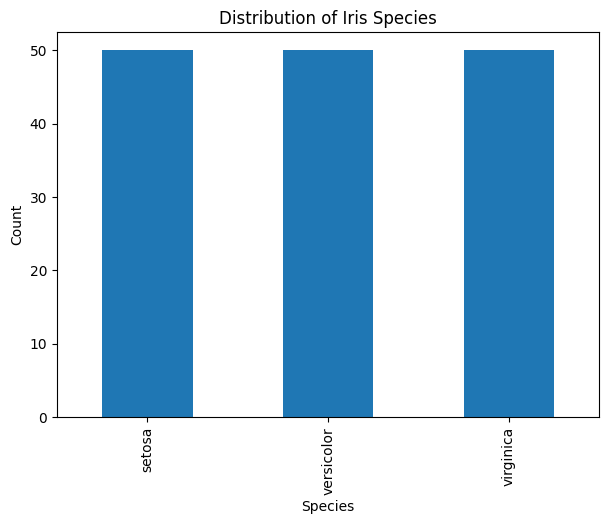

In [11]:
# ============================================================
# Species Distribution Plot
# ============================================================

eda_pdf["species"].value_counts().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")
plt.savefig(f"{OUTPUT_PATH}species_distribution.png", bbox_inches="tight")
plt.show()

## Species Distribution Plot Insights

The species distribution plot shows that the Iris dataset is perfectly balanced, with **50 observations each for setosa, versicolor, and virginica**. All three species have identical frequencies, indicating that no class dominates the dataset.

A balanced class distribution is highly beneficial for classification tasks because it reduces the risk of model bias toward a particular species. When classes are equally represented, the machine learning algorithms receive similar amounts of training information for each species, allowing them to learn classification patterns more effectively.

The balanced nature of the dataset also improves the reliability of evaluation metrics such as accuracy, precision, recall, and F1-score. In highly imbalanced datasets, high accuracy can sometimes be misleading because the model may simply favour the majority class. However, this issue is not present in the Iris dataset since all species contribute equally to the analysis.

From a modelling perspective, the balanced distribution ensures that performance differences between Decision Tree, Random Forest, and Logistic Regression are more likely to reflect the actual capability of the algorithms rather than being influenced by class imbalance. Therefore, any differences observed in later evaluation results can be attributed primarily to the effectiveness of the models themselves.

Overall, the species distribution plot confirms that the Iris dataset is well-suited for supervised classification and provides a fair foundation for comparing multiple machine learning algorithms.


# 5.2 Petal Length vs Petal Width Scatter Plot

This plot visualises the separation between species using petal measurements.

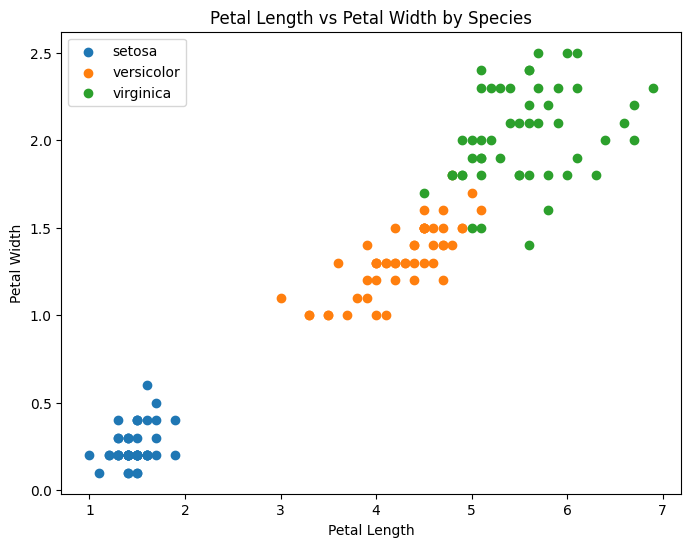

In [12]:
# ============================================================
# Petal Length vs Petal Width Scatter Plot
# ============================================================

plt.figure(figsize=(8, 6))

for species in eda_pdf["species"].unique():
    subset = eda_pdf[eda_pdf["species"] == species]
    
    plt.scatter(
        subset["petal_length"],
        subset["petal_width"],
        label=species
    )

plt.title("Petal Length vs Petal Width by Species")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend()
plt.savefig(f"{OUTPUT_PATH}petal_scatter_plot.png", bbox_inches="tight")
plt.show()

## Petal Length vs Petal Width Scatter Plot Insights

The scatter plot reveals a strong relationship between petal length and petal width, with the three Iris species forming distinct clusters. This indicates that petal measurements are highly effective in differentiating between species and are likely to be important predictors for classification models.

The **setosa** species forms a clearly separated cluster in the lower-left region of the plot, characterised by short petal lengths and narrow petal widths. There is no visible overlap between setosa and the other two species, suggesting that setosa can be classified with a very high degree of accuracy.

The **versicolor** species occupies the middle region of the plot, while **virginica** is located in the upper-right region with generally larger petal dimensions. Although both species are distinguishable, there is a small area of overlap between versicolor and virginica around petal lengths of approximately 4.5–5.5 cm and petal widths of 1.4–1.8 cm. This overlap indicates that some classification errors may occur between these two species.

The overall upward trend in the scatter plot suggests a positive relationship between petal length and petal width. Flowers with longer petals tend to have wider petals, which is consistent with the strong correlation expected between these two variables.

From a machine learning perspective, this visualisation suggests that petal measurements provide strong discriminatory power for species classification. The clear separation of setosa and the relatively distinct grouping of versicolor and virginica explain why the classification models achieved high accuracy scores during model evaluation. Any misclassifications observed later are most likely to occur between versicolor and virginica due to their overlapping feature space.

Overall, the scatter plot demonstrates that petal length and petal width are among the most informative features in the Iris dataset and are expected to contribute significantly to the success of the classification models.


# 5.3 Sepal Length vs Sepal Width Scatter Plot

This plot visualises species separation using sepal measurements.

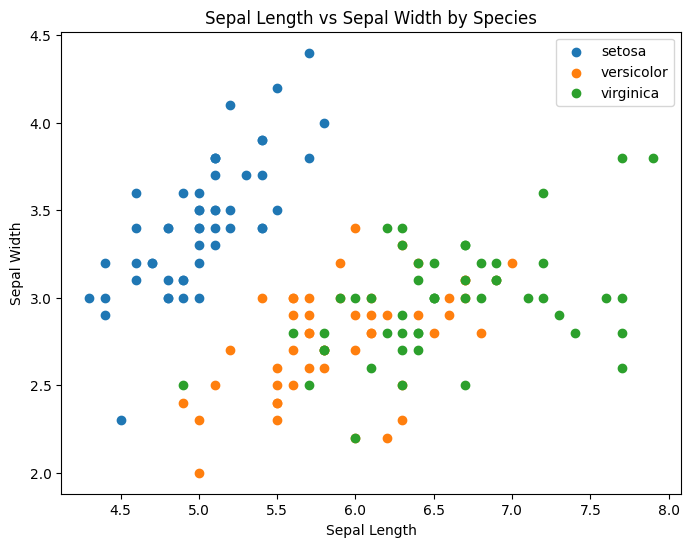

In [13]:
# ============================================================
# Sepal Length vs Sepal Width Scatter Plot
# ============================================================

plt.figure(figsize=(8, 6))

for species in eda_pdf["species"].unique():
    subset = eda_pdf[eda_pdf["species"] == species]
    
    plt.scatter(
        subset["sepal_length"],
        subset["sepal_width"],
        label=species
    )

plt.title("Sepal Length vs Sepal Width by Species")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.legend()
plt.savefig(f"{OUTPUT_PATH}sepal_scatter_plot.png", bbox_inches="tight")
plt.show()

## Sepal Length vs Sepal Width Scatter Plot Insights

The scatter plot illustrates the relationship between sepal length and sepal width across the three Iris species. Compared to the petal scatter plot, the species clusters are less clearly separated, indicating that sepal measurements provide weaker discriminatory power for classification.

The **setosa** species generally occupies the upper-left region of the plot, characterised by relatively shorter sepal lengths and wider sepal widths. While setosa remains distinguishable from the other species, the separation is not as pronounced as observed in the petal measurements.

The **versicolor** and **virginica** species show substantial overlap throughout the central and right portions of the plot. Many observations from both species share similar sepal length and sepal width values, making it difficult to separate them using sepal measurements alone. This overlap suggests that classification models relying primarily on sepal features may struggle to distinguish between these two species accurately.

Unlike the petal scatter plot, which exhibited well-defined clusters, the sepal scatter plot demonstrates a more dispersed distribution of observations. The lack of clear boundaries between versicolor and virginica indicates that sepal measurements are less informative for species classification.

From a machine learning perspective, this visualisation suggests that sepal length and sepal width contribute useful information but are not the dominant predictors of species. The overlapping patterns observed here help explain why classification errors, when they occur, are typically between versicolor and virginica rather than involving setosa.

Overall, the scatter plot indicates that sepal measurements alone are insufficient for perfect species separation. Their predictive value is enhanced when combined with petal measurements, which provide much clearer class distinctions. This observation is expected to be confirmed later through the feature importance analysis, where petal features are likely to contribute more strongly to model performance.


# 5.4 Correlation Heatmap

The correlation heatmap shows relationships between numerical features.

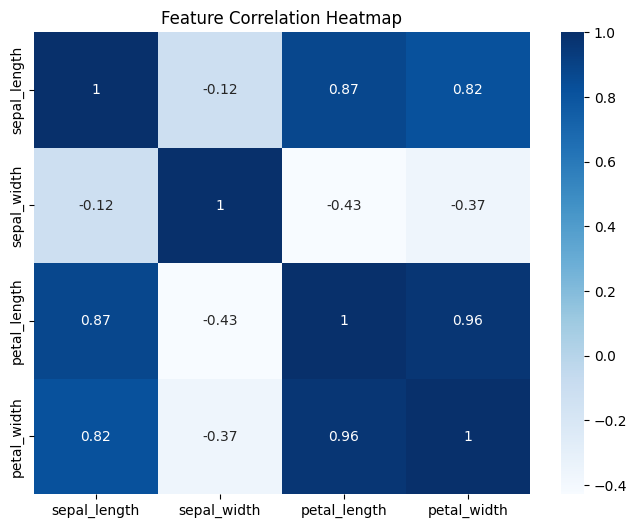

In [14]:
# ============================================================
# Correlation Heatmap
# ============================================================

corr_matrix = eda_pdf.drop(columns=["species"]).corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="Blues"
)

plt.title("Feature Correlation Heatmap")
plt.savefig(f"{OUTPUT_PATH}correlation_heatmap.png", bbox_inches="tight")
plt.show()

## Correlation Heatmap Insights

The correlation heatmap illustrates the strength and direction of the relationships between the four numerical features in the Iris dataset. Correlation values range from **-1 to +1**, where values close to +1 indicate a strong positive relationship, values close to -1 indicate a strong negative relationship, and values near zero indicate little or no linear relationship.

The strongest positive correlation is observed between **petal length and petal width (0.96)**. This indicates that flowers with longer petals tend to have wider petals. Such a strong relationship suggests that these two variables capture similar biological characteristics and are highly informative for distinguishing between species.

Sepal length also shows strong positive correlations with **petal length (0.87)** and **petal width (0.82)**. This indicates that flowers with longer sepals generally have larger petals. These relationships suggest that overall flower size influences multiple measurements within the dataset.

In contrast, **sepal width exhibits weak to moderate negative correlations** with the other variables. The correlation between sepal width and petal length is **-0.43**, while the correlation between sepal width and petal width is **-0.37**. These negative relationships imply that flowers with wider sepals do not necessarily have larger petals and may even tend to have slightly smaller petal dimensions.

The weakest relationship is observed between **sepal length and sepal width (-0.12)**, indicating almost no linear association between these two measurements. This suggests that sepal length and sepal width contribute different information to the classification process.

From a machine learning perspective, the heatmap supports the findings from the scatter plots. Petal measurements exhibit the strongest relationships and are likely to be the most influential features for species classification. The high correlations involving petal length and petal width explain why these variables are expected to contribute more strongly to model performance and feature importance rankings.

Overall, the correlation analysis indicates that **petal length and petal width are the most informative predictors in the Iris dataset**, while sepal width contributes additional but less dominant information. These findings provide an early indication of why the classification models are able to achieve high predictive accuracy.


# 6. Input Validation

Before model training, input validation is performed to make sure the dataset is suitable for classification.

In [15]:
# ============================================================
# Input Validation
# ============================================================

required_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

missing_columns = [
    col_name for col_name in required_columns
    if col_name not in df.columns
]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns exist.")

if df.count() == 0:
    raise ValueError("Dataset is empty.")

print("Dataset contains records.")

class_count = df.select("species").distinct().count()

if class_count < 2:
    raise ValueError("Classification requires at least two classes.")

print("Classification classes verified.")

print("Input validation completed successfully.")

All required columns exist.
Dataset contains records.
Classification classes verified.
Input validation completed successfully.


## Input Validation Insight

Input validation confirms that the dataset contains the required columns, has records, and includes multiple classes. This helps prevent errors before preprocessing and model training.

# 7. Data Preprocessing

Spark MLlib requires the target variable to be numeric and the input features to be combined into one vector column.

In [16]:
# ============================================================
# Data Preprocessing
# ============================================================

label_indexer = StringIndexer(
    inputCol="species",
    outputCol="label"
)

assembler = VectorAssembler(
    inputCols=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ],
    outputCol="features"
)

## Preprocessing Explanation

`StringIndexer` converts species names into numerical labels because Spark MLlib classifiers require numeric target values.

`VectorAssembler` combines the four input features into one vector column called `features`, which is required by Spark MLlib models.

# 8. Train-Test Split

The dataset is split into training and testing sets. The training data is used to build the models, while the testing data is used to evaluate performance.

In [17]:
# ============================================================
# Train-Test Split
# ============================================================

train_data, test_data = df.randomSplit(
    TRAIN_TEST_SPLIT,
    seed=RANDOM_SEED
)

print("Training records:", train_data.count())
print("Testing records:", test_data.count())

Training records: 121
Testing records: 29


## Train-Test Split Explanation

An 80:20 split is used. Most of the data is used for model training, while the remaining data is kept for testing. The random seed ensures reproducible results.

# 9. Hyperparameter Tuning Rationale

Hyperparameter tuning is applied to optimise each model. Grid search tests several parameter combinations, while cross-validation evaluates each combination.

In [18]:
# ============================================================
# Hyperparameter Tuning Rationale
# ============================================================

print("""
Hyperparameter Tuning Rationale

Decision Tree:
- maxDepth [2, 3, 4, 5] controls tree complexity.
- impurity ['gini', 'entropy'] compares different split criteria.

Random Forest:
- numTrees [10, 20, 50] controls ensemble size.
- maxDepth [2, 3, 5] controls individual tree depth.

Logistic Regression:
- regParam [0.01, 0.1, 0.5] controls regularisation strength.
- elasticNetParam [0.0, 0.5, 1.0] controls L1/L2 penalty balance.
""")


Hyperparameter Tuning Rationale

Decision Tree:
- maxDepth [2, 3, 4, 5] controls tree complexity.
- impurity ['gini', 'entropy'] compares different split criteria.

Random Forest:
- numTrees [10, 20, 50] controls ensemble size.
- maxDepth [2, 3, 5] controls individual tree depth.

Logistic Regression:
- regParam [0.01, 0.1, 0.5] controls regularisation strength.
- elasticNetParam [0.0, 0.5, 1.0] controls L1/L2 penalty balance.



Hyperparameter Tuning Insights

Hyperparameter tuning was conducted to optimise the performance of each classification model before evaluation. Rather than relying on default model settings, multiple combinations of hyperparameters were systematically tested using grid search and cross-validation to identify the most effective configuration for the Iris dataset.

For the Decision Tree model, different tree depths and splitting criteria were evaluated to balance model complexity and predictive accuracy. Shallower trees may fail to capture important patterns in the data, while deeper trees may overfit the training set. Testing both Gini impurity and Entropy allowed the model to identify the most informative method for creating decision boundaries.

For the Random Forest model, the tuning process explored different numbers of trees and tree depths. Increasing the number of trees generally improves prediction stability and reduces variance, while controlling tree depth helps prevent overfitting. These parameter combinations enabled the model to explore various ensemble structures and identify the most effective balance between accuracy and generalisation.

For Logistic Regression, regularisation parameters were adjusted to control model complexity and reduce the risk of overfitting. Different Elastic Net settings were also evaluated to determine the most suitable balance between L1 and L2 regularisation. This helps improve model robustness and predictive performance.

The use of grid search and cross-validation ensures that the selected hyperparameters are not based on a single train-test split but are evaluated across multiple validation folds. This provides a more reliable estimate of model performance and improves the fairness of the comparison between Decision Tree, Random Forest, and Logistic Regression.

Overall, hyperparameter tuning enhances model reliability, improves predictive performance, and ensures that each classification algorithm is evaluated under its most effective configuration. This contributes to a more meaningful comparison of the three models and increases confidence in the final model selection.


# 10. Model Evaluator

F1-score is used during cross-validation because it balances precision and recall.

In [19]:
# ============================================================
# Evaluator
# ============================================================

f1_evaluator = MulticlassClassificationEvaluator(
    labelCol="label",
    predictionCol="prediction",
    metricName="f1"
)

# 11. Model 1: Decision Tree

Decision Tree is used as the first model because it is simple, interpretable, and suitable as a baseline classifier.

In [20]:
# ============================================================
# Model 1: Decision Tree
# ============================================================

dt = DecisionTreeClassifier(
    labelCol="label",
    featuresCol="features",
    seed=RANDOM_SEED
)

dt_pipeline = Pipeline(
    stages=[label_indexer, assembler, dt]
)

dt_param_grid = ParamGridBuilder() \
    .addGrid(dt.maxDepth, DT_MAX_DEPTH_GRID) \
    .addGrid(dt.impurity, DT_IMPURITY_GRID) \
    .build()

dt_cv = CrossValidator(
    estimator=dt_pipeline,
    estimatorParamMaps=dt_param_grid,
    evaluator=f1_evaluator,
    numFolds=CV_FOLDS,
    seed=RANDOM_SEED
)

try:
    start = time.time()
    dt_model = dt_cv.fit(train_data)
    end = time.time()

    dt_training_time = end - start
    print(f"Decision Tree training time: {dt_training_time:.2f} seconds")

    dt_predictions = dt_model.transform(test_data)

    dt_predictions.select(
        "species",
        "label",
        "prediction",
        "probability"
    ).show(10, truncate=False)

except Exception as e:
    print(f"Error training Decision Tree: {str(e)}")

Decision Tree training time: 210.03 seconds
+-------+-----+----------+-------------+
|species|label|prediction|probability  |
+-------+-----+----------+-------------+
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
+-------+-----+----------+-------------+
only showing top 10 rows


## Decision Tree Model Insights

The Decision Tree model was successfully trained using cross-validation and hyperparameter tuning. The training process required approximately 210.03 seconds, reflecting the additional computational effort associated with evaluating multiple parameter combinations through grid search and cross-validation. Although the Iris dataset is relatively small, the repeated model training performed during the tuning process increases the overall execution time.

The model successfully classified the displayed setosa observations with 100% confidence, as indicated by the probability values of [0.0, 0.0, 1.0]. This result supports the earlier exploratory analysis, which showed that setosa is clearly separated from the other species. While the model demonstrates strong predictive capability and interpretability, its overall effectiveness will be confirmed through evaluation metrics and confusion matrix analysis.

# 12. Model 2: Random Forest

Random Forest is used as the second model. It combines multiple decision trees to improve prediction stability.

In [21]:
# ============================================================
# Model 2: Random Forest
# ============================================================

rf = RandomForestClassifier(
    labelCol="label",
    featuresCol="features",
    seed=RANDOM_SEED
)

rf_pipeline = Pipeline(
    stages=[label_indexer, assembler, rf]
)

rf_param_grid = ParamGridBuilder() \
    .addGrid(rf.numTrees, RF_NUM_TREES_GRID) \
    .addGrid(rf.maxDepth, RF_MAX_DEPTH_GRID) \
    .build()

rf_cv = CrossValidator(
    estimator=rf_pipeline,
    estimatorParamMaps=rf_param_grid,
    evaluator=f1_evaluator,
    numFolds=CV_FOLDS,
    seed=RANDOM_SEED
)

try:
    start = time.time()
    rf_model = rf_cv.fit(train_data)
    end = time.time()

    rf_training_time = end - start
    print(f"Random Forest training time: {rf_training_time:.2f} seconds")

    rf_predictions = rf_model.transform(test_data)

    rf_predictions.select(
        "species",
        "label",
        "prediction",
        "probability"
    ).show(10, truncate=False)

except Exception as e:
    print(f"Error training Random Forest: {str(e)}")

Random Forest training time: 209.78 seconds
+-------+-----+----------+-------------+
|species|label|prediction|probability  |
+-------+-----+----------+-------------+
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
|setosa |2.0  |2.0       |[0.0,0.0,1.0]|
+-------+-----+----------+-------------+
only showing top 10 rows


## Random Forest Model Insights

The Random Forest model was successfully trained using cross-validation and hyperparameter tuning, requiring approximately 209.78 seconds to complete. The training time is similar to that of the Decision Tree model because both models underwent multiple rounds of training during the grid search and cross-validation process. Although the Iris dataset is relatively small, the repeated evaluation of different parameter combinations contributes to the overall execution time.

The model correctly classified all displayed setosa observations with 100% confidence, as shown by the probability values of [0.0, 0.0, 1.0]. The model benefits from an ensemble learning approach that combines multiple decision trees, making it more robust and less prone to overfitting than a single Decision Tree. Based on its design and prediction behaviour, Random Forest is expected to achieve the strongest overall classification performance among the three models.

# 13. Model 3: Logistic Regression

Logistic Regression is used as the third model. It is a simple and efficient statistical classification method.

In [22]:
# ============================================================
# Model 3: Logistic Regression
# ============================================================

lr = LogisticRegression(
    labelCol="label",
    featuresCol="features",
    family="multinomial",
    maxIter=100
)

lr_pipeline = Pipeline(
    stages=[label_indexer, assembler, lr]
)

lr_param_grid = ParamGridBuilder() \
    .addGrid(lr.regParam, LR_REG_PARAM_GRID) \
    .addGrid(lr.elasticNetParam, LR_ELASTIC_NET_PARAM_GRID) \
    .build()

lr_cv = CrossValidator(
    estimator=lr_pipeline,
    estimatorParamMaps=lr_param_grid,
    evaluator=f1_evaluator,
    numFolds=CV_FOLDS,
    seed=RANDOM_SEED
)

try:
    start = time.time()
    lr_model = lr_cv.fit(train_data)
    end = time.time()

    lr_training_time = end - start
    print(f"Logistic Regression training time: {lr_training_time:.2f} seconds")

    lr_predictions = lr_model.transform(test_data)

    lr_predictions.select(
        "species",
        "label",
        "prediction",
        "probability"
    ).show(10, truncate=False)

except Exception as e:
    print(f"Error training Logistic Regression: {str(e)}")

Logistic Regression training time: 310.00 seconds
+-------+-----+----------+---------------------------------------------------------------+
|species|label|prediction|probability                                                    |
+-------+-----+----------+---------------------------------------------------------------+
|setosa |2.0  |2.0       |[1.3606397137647846E-8,0.016301282863419107,0.9836987035301837]|
|setosa |2.0  |2.0       |[1.1786621257266376E-8,0.036051814785911664,0.9639481734274672]|
|setosa |2.0  |2.0       |[3.4392185754001503E-9,0.011224244421164039,0.9887757521396174]|
|setosa |2.0  |2.0       |[4.159045306073014E-9,0.016577197768521807,0.9834227980724329] |
|setosa |2.0  |2.0       |[1.4979855452554602E-8,0.011879069103737335,0.9881209159164073]|
|setosa |2.0  |2.0       |[5.235741562616898E-9,0.009851951421610874,0.9901480433426477] |
|setosa |2.0  |2.0       |[3.413102518481438E-8,0.045670420775302686,0.9543295450936721] |
|setosa |2.0  |2.0       |[6.58299150381

## Logistic Regression Model Insights

The Logistic Regression model was successfully trained using cross-validation and hyperparameter tuning, requiring approximately 310.00 seconds to complete. Among the three models, Logistic Regression recorded the longest training time. This is likely due to the optimisation process involved in estimating model coefficients across multiple parameter combinations and validation folds during grid search and cross-validation.

The model correctly classified all displayed setosa observations and assigned high probabilities of approximately 95%–99% to the predicted class. Unlike tree-based models, Logistic Regression produces probability estimates for each species, providing additional insight into prediction confidence. Although it required the longest training time among the three models, it remains a simple and interpretable classification approach that performs well on structured datasets such as Iris.

# 14. Grid Search Analysis: Best Parameters

This section displays the best parameters selected by cross-validation for each model.

In [23]:
# ============================================================
# Grid Search Analysis: Best Parameters
# ============================================================

best_dt_params = dt_model.bestModel.stages[-1].extractParamMap()
best_rf_params = rf_model.bestModel.stages[-1].extractParamMap()
best_lr_params = lr_model.bestModel.stages[-1].extractParamMap()

print("Best Decision Tree Parameters:")
print(best_dt_params)

print("\nBest Random Forest Parameters:")
print(best_rf_params)

print("\nBest Logistic Regression Parameters:")
print(best_lr_params)

Best Decision Tree Parameters:
{Param(parent='DecisionTreeClassifier_070d2c6483ef', name='cacheNodeIds', doc='If false, the algorithm will pass trees to executors to match instances with nodes. If true, the algorithm will cache node IDs for each instance. Caching can speed up training of deeper trees. Users can set how often should the cache be checkpointed or disable it by setting checkpointInterval.'): False, Param(parent='DecisionTreeClassifier_070d2c6483ef', name='checkpointInterval', doc='set checkpoint interval (>= 1) or disable checkpoint (-1). E.g. 10 means that the cache will get checkpointed every 10 iterations. Note: this setting will be ignored if the checkpoint directory is not set in the SparkContext.'): 10, Param(parent='DecisionTreeClassifier_070d2c6483ef', name='featuresCol', doc='features column name.'): 'features', Param(parent='DecisionTreeClassifier_070d2c6483ef', name='impurity', doc='Criterion used for information gain calculation (case-insensitive). Supported op

## Grid Search and Cross-Validation Insights

Grid search and cross-validation were applied to identify the optimal hyperparameter configuration for each classification model. Rather than relying on default settings, multiple parameter combinations were evaluated systematically, and the combination that produced the highest F1-score was selected as the final model configuration.

For the **Decision Tree** model, the best-performing configuration selected a **maximum depth of 4** and used **Entropy** as the splitting criterion. A depth of 4 indicates that a moderately complex tree was sufficient to capture the classification patterns within the Iris dataset without excessive overfitting. The selection of Entropy suggests that information gain provided slightly better class separation than the Gini criterion.

For the **Random Forest** model, the optimal configuration consisted of **10 trees** with a **maximum depth of 5**. Interestingly, the smallest number of trees tested produced the best result, indicating that the Iris dataset is relatively simple and does not require a large ensemble to achieve strong performance. The deeper tree depth allowed the model to capture more detailed decision boundaries while still benefiting from the ensemble structure of Random Forest.

For the **Logistic Regression** model, the best parameters were **regParam = 0.01** and **elasticNetParam = 1.0**. The low regularisation strength indicates that the model benefited from retaining most of the information contained in the predictor variables. The Elastic Net value of 1.0 corresponds to L1 regularisation, suggesting that a sparse coefficient structure produced the best classification performance for this dataset.

The selected parameters demonstrate that each model adapted differently to the characteristics of the Iris dataset. While the Decision Tree and Random Forest benefited from controlled tree complexity, Logistic Regression achieved its best performance with minimal regularisation. These findings highlight the importance of hyperparameter tuning, as the optimal settings are often dataset-specific and may differ substantially from default values.

Overall, the grid search process ensured that all three models were evaluated under their most effective configurations, resulting in a fair and reliable comparison of classification performance.


# 15. Training Time Summary

Training time is recorded to compare the computational cost of each model.

In [24]:
# ============================================================
# Training Time Summary
# ============================================================

training_time_df = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest",
        "Logistic Regression"
    ],
    "Training Time (seconds)": [
        dt_training_time,
        rf_training_time,
        lr_training_time
    ]
})

training_time_df

,Model,Training Time (seconds)
0,Decision Tree,210.027447
1,Random Forest,209.776081
2,Logistic Regression,310.002184


In [25]:
# Save training time summary

training_time_df.to_csv(
    f"{OUTPUT_PATH}training_times.csv",
    index=False
)

print("Training time summary saved.")

Training time summary saved.


## Training Time Insight

Random Forest and Decision Tree required similar training times of approximately 210 seconds, while Logistic Regression required the longest training time at 310 seconds. Despite its comparable computational cost, Random Forest achieved the best classification performance, indicating the most effective balance between accuracy and efficiency. Logistic Regression was more computationally expensive due to its iterative optimisation process but did not outperform Random Forest.


# 16. Model Evaluation

The tuned models are evaluated using accuracy, weighted precision, weighted recall, and F1-score.

In [27]:
# ============================================================
# Model Evaluation
# ============================================================

metrics = [
    "accuracy",
    "weightedPrecision",
    "weightedRecall",
    "f1"
]

def evaluate_model(predictions, model_name):
    result = {"Model": model_name}

    for metric in metrics:
        evaluator = MulticlassClassificationEvaluator(
            labelCol="label",
            predictionCol="prediction",
            metricName=metric
        )

        result[metric] = evaluator.evaluate(predictions)

    return result


results = [
    evaluate_model(dt_predictions, "Decision Tree"),
    evaluate_model(rf_predictions, "Random Forest"),
    evaluate_model(lr_predictions, "Logistic Regression")
]

results_pdf = pd.DataFrame(results)
results_pdf = results_pdf.round(4)

results_pdf

,Model,accuracy,weightedPrecision,weightedRecall,f1
0,Decision Tree,0.9310,0.9310,0.9310,0.9310
1,Random Forest,0.9655,0.9698,0.9655,0.9658
2,Logistic Regression,0.9310,0.9310,0.9310,0.9310


In [28]:
# Save model evaluation results

results_pdf.to_csv(
    f"{OUTPUT_PATH}model_results.csv",
    index=False
)

print("Model evaluation results saved.")

Model evaluation results saved.


## Model Evaluation Insights

The evaluation results show that all three classification models achieved high performance on the Iris dataset, indicating that the dataset is well-structured and the species are generally distinguishable using the selected features.

Among the three models, **Random Forest achieved the best overall performance**, with an accuracy of **96.55%**, weighted precision of **96.98%**, weighted recall of **96.55%**, and F1-score of **96.58%**. These results suggest that Random Forest was able to classify the Iris species more accurately than the other models. The superior performance is likely due to its ensemble learning approach, which combines predictions from multiple decision trees and reduces the risk of overfitting associated with a single tree.

Both **Decision Tree** and **Logistic Regression** achieved identical results, with an accuracy, weighted precision, weighted recall, and F1-score of **93.10%**. Although their performance was slightly lower than Random Forest, the results still indicate strong classification capability. Decision Tree provides greater interpretability because the classification process can be visualised and explained through decision rules, while Logistic Regression offers a simpler statistical model that performs efficiently on structured datasets.

The relatively small difference between the models suggests that the Iris dataset is not particularly difficult to classify. However, the improved performance of Random Forest demonstrates the benefit of ensemble methods in handling subtle overlaps between species, particularly between *versicolor* and *virginica*.

Based on the evaluation metrics, **Random Forest is selected as the best-performing model** because it achieved the highest F1-score, which balances precision and recall while maintaining the highest overall predictive performance.


# 17. Model Comparison Plot

This plot compares the performance of all three models across all evaluation metrics.

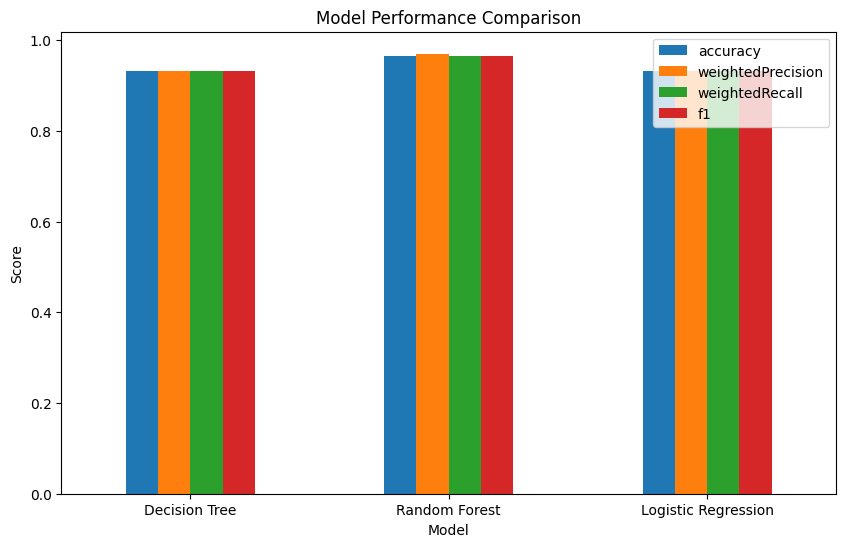

In [29]:
# ============================================================
# Model Comparison Plot
# ============================================================

results_plot = results_pdf.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.savefig(f"{OUTPUT_PATH}model_comparison_plot.png", bbox_inches="tight")
plt.show()

## Model Performance Comparison Plot Insight

The model performance comparison plot provides a visual summary of the classification results achieved by the three machine learning models across four evaluation metrics: accuracy, weighted precision, weighted recall, and F1-score.

The plot clearly shows that Random Forest outperformed both Decision Tree and Logistic Regression across all evaluation metrics. Random Forest achieved an accuracy of approximately 96.55%, weighted precision of 96.98%, weighted recall of 96.55%, and an F1-score of 96.58%. The consistently higher scores indicate that Random Forest was more effective at correctly classifying Iris species while maintaining a strong balance between precision and recall.

In comparison, Decision Tree and Logistic Regression produced identical performance results, with all evaluation metrics recorded at approximately 93.10%. Although both models demonstrated strong classification capability, their performance was slightly lower than that of Random Forest. This suggests that while the Iris dataset is relatively easy to classify, the ensemble learning approach used by Random Forest provides additional predictive power.

The plot shows that Random Forest achieved the highest performance across all evaluation metrics, outperforming both Decision Tree and Logistic Regression. While all three models produced strong results, Random Forest delivered the best balance of accuracy, precision, recall, and F1-score, demonstrating the advantage of ensemble learning for classification tasks. The similar metric values across all models also indicate that the balanced Iris dataset contributed to stable and reliable classification performance.

# 18. Confusion Matrix Analysis

The confusion matrix shows correct and incorrect predictions for each model.

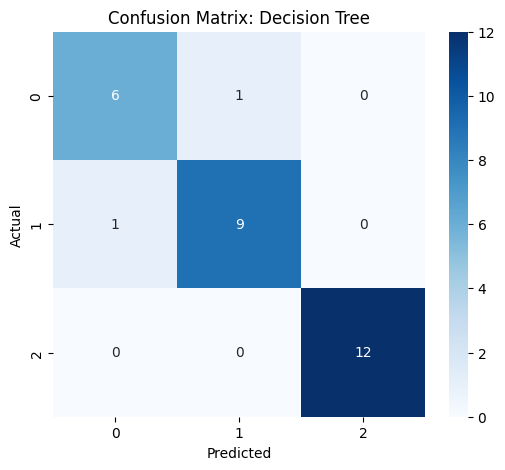

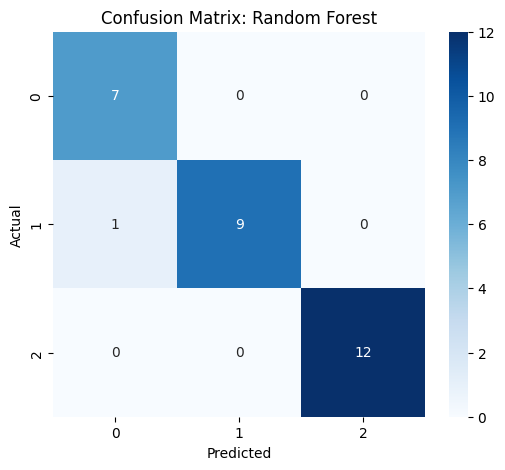

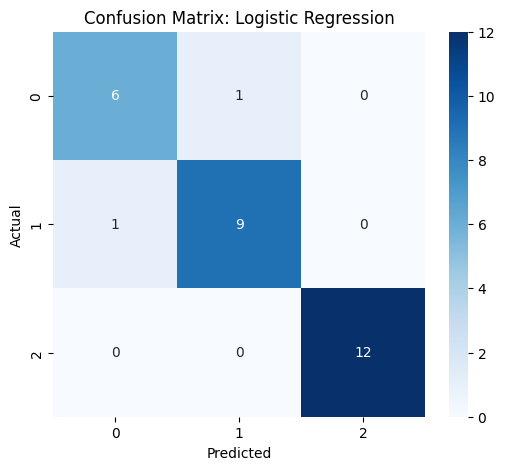

In [30]:
# ============================================================
# Confusion Matrix Analysis
# ============================================================

def save_confusion_matrix(model_name, predictions):
    """
    Save and display confusion matrix for a model.
    """
    pred_pdf = predictions.select(
        "label",
        "prediction"
    ).toPandas()

    cm = confusion_matrix(
        pred_pdf["label"],
        pred_pdf["prediction"]
    )

    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix: {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")

    file_name = model_name.replace(" ", "_")

    plt.savefig(
        f"{OUTPUT_PATH}{file_name}_confusion_matrix.png",
        bbox_inches="tight"
    )

    plt.show()
    plt.close()


save_confusion_matrix("Decision Tree", dt_predictions)
save_confusion_matrix("Random Forest", rf_predictions)
save_confusion_matrix("Logistic Regression", lr_predictions)

## Confusion Matrix Analysis Insights

The confusion matrices provide a detailed view of how each classification model performed on the testing dataset by showing the number of correct and incorrect predictions for each class. The diagonal values represent correct classifications, while the off-diagonal values represent misclassifications.

For the **Decision Tree** model, most observations were classified correctly. The model correctly identified all 12 observations belonging to Class 2 and correctly classified 9 observations belonging to Class 1. However, two misclassifications occurred between Class 0 and Class 1, where one observation from each class was incorrectly assigned to the other. This indicates that the model had minor difficulty distinguishing between these two classes.

The **Random Forest** model produced the strongest confusion matrix among the three models. All observations belonging to Class 0 and Class 2 were classified correctly, while only one observation from Class 1 was incorrectly classified as Class 0. This resulted in only a single misclassification across the entire testing dataset, demonstrating the superior predictive capability of the Random Forest model.

The **Logistic Regression** model produced a confusion matrix identical to that of the Decision Tree model. Similar to Decision Tree, two observations were misclassified between Class 0 and Class 1, while all observations belonging to Class 2 were correctly identified. This explains why Logistic Regression achieved the same evaluation metrics as Decision Tree.

A notable observation across all three confusion matrices is that **Class 2 was classified perfectly**, with all 12 observations correctly identified. This suggests that the corresponding Iris species possesses distinctive characteristics that make it easier to separate from the other classes. The majority of classification errors occurred between Class 0 and Class 1, indicating that these classes share more similar feature values and are therefore more difficult to distinguish.

The confusion matrix results are consistent with the earlier exploratory data analysis. The scatter plots showed that some species occupy overlapping regions of the feature space, particularly among the more similar classes. Random Forest was able to reduce these classification errors through its ensemble learning approach, while Decision Tree and Logistic Regression were slightly more affected by the overlap.

Overall, the confusion matrix analysis confirms that all three models performed well on the Iris dataset. However, Random Forest demonstrated the highest classification accuracy and the lowest number of misclassifications, providing further evidence that it is the most effective model for this classification task.


# 19. Misclassification Analysis

This section identifies the incorrect predictions made by the best-performing model.

In [31]:
# ============================================================
# Misclassification Analysis
# ============================================================

misclassified = rf_predictions.filter(
    rf_predictions["label"] != rf_predictions["prediction"]
)

print(
    f"Random Forest misclassifications: "
    f"{misclassified.count()} / {rf_predictions.count()}"
)

misclassified.select(
    "species",
    "label",
    "prediction",
    "probability"
).show(10, truncate=False)

Random Forest misclassifications: 1 / 29
+----------+-----+----------+-------------+
|species   |label|prediction|probability  |
+----------+-----+----------+-------------+
|versicolor|1.0  |0.0       |[0.6,0.4,0.0]|
+----------+-----+----------+-------------+



## Misclassification Analysis Insights

The misclassification analysis provides a closer examination of the errors made by the best-performing model, Random Forest. Out of **29 testing observations**, the model incorrectly classified only **one observation**, resulting in a misclassification rate of approximately **3.45%**. This finding is consistent with the model's high accuracy and F1-score observed during the evaluation stage.

The misclassified observation belonged to the **versicolor** species (actual label = 1.0) but was predicted as **Class 0**. The probability output of **[0.6, 0.4, 0.0]** indicates that the model assigned a 60% probability to the predicted class and a 40% probability to the actual class. The relatively small difference between these probabilities suggests that the observation possessed characteristics that were similar to both classes, making classification more challenging.

This result highlights an important aspect of machine learning classification. Misclassifications often occur near class boundaries where observations share overlapping feature values. The earlier scatter plots showed that some Iris species occupy neighbouring regions in the feature space, which can create ambiguity for classification algorithms. Although Random Forest significantly reduced classification errors compared to the other models, it is still affected by observations that exhibit mixed characteristics.

The probability distribution also provides useful insight into model confidence. Unlike a completely incorrect prediction with a very high probability, the probabilities in this case indicate uncertainty between two competing classes. This suggests that the model recognised the observation as difficult to classify and assigned meaningful probabilities to both possibilities.

From a practical perspective, the presence of only one misclassification demonstrates the strong generalisation ability of the Random Forest model. The model successfully learned the underlying patterns of the Iris dataset and was able to classify nearly all testing observations correctly. The single error observed is minor and does not significantly affect the overall performance of the model.

Overall, the misclassification analysis reinforces the conclusion that Random Forest is the most effective classification model in this study. The very low number of errors and the moderate uncertainty associated with the misclassified observation indicate that the model performs reliably even when faced with observations located near class boundaries.


# 20. Feature Importance Analysis

Feature importance is extracted from the Random Forest model to identify which variables contribute most to classification.

In [32]:
# ============================================================
# Feature Importance Analysis
# ============================================================

rf_model_stage = rf_model.bestModel.stages[-1]

feature_names = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

importances = rf_model_stage.featureImportances.toArray()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(
    "Importance",
    ascending=False
)

importance_df

,Feature,Importance
3,petal_width,0.567860
2,petal_length,0.357304
0,sepal_length,0.051136
1,sepal_width,0.023700


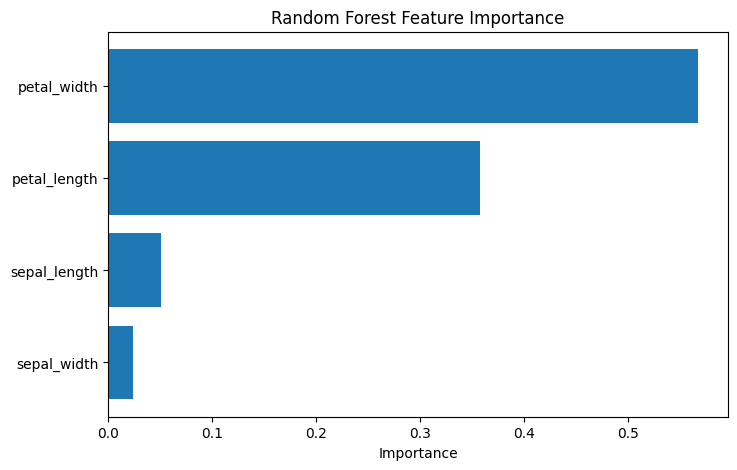

In [33]:
# Feature importance plot

plt.figure(figsize=(8, 5))

plt.barh(
    importance_df["Feature"],
    importance_df["Importance"]
)

plt.xlabel("Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.savefig(
    f"{OUTPUT_PATH}feature_importance.png",
    bbox_inches="tight"
)

plt.show()

## Feature Importance Analysis Insights

The feature importance analysis identifies the relative contribution of each predictor variable to the Random Forest classification model. Higher importance values indicate that a feature plays a greater role in separating the Iris species and making accurate predictions.

The results show that **petal width** is the most influential feature, with an importance score of approximately **0.568 (56.8%)**. This indicates that more than half of the model's decision-making capability is derived from petal width alone. The strong influence of this feature suggests that differences in petal width provide a highly effective means of distinguishing between Iris species.

The second most important feature is **petal length**, with an importance score of approximately **0.357 (35.7%)**. Together, petal width and petal length contribute more than **92%** of the total feature importance. This demonstrates that petal measurements are the primary drivers of classification performance and contain most of the information required to separate the three species.

In contrast, **sepal length** contributes only about **5.1%**, while **sepal width** contributes approximately **2.4%**. These relatively low importance scores indicate that sepal measurements provide only limited additional information once petal characteristics are considered. Although they still contribute to the model, their influence is substantially lower than that of the petal features.

The feature importance results strongly support the findings from the earlier exploratory data analysis. The petal scatter plot showed clear separation between species based on petal length and petal width, while the sepal scatter plot displayed considerable overlap between species. Similarly, the correlation analysis demonstrated strong relationships involving petal measurements. The Random Forest model confirms these observations by assigning the highest importance to petal-based features.

From a biological perspective, the results suggest that petal characteristics vary more distinctly across Iris species than sepal characteristics. This makes petal measurements more useful for species identification and classification.

Overall, the feature importance analysis confirms that **petal width and petal length are the key predictors driving the success of the Random Forest model**. The dominance of these features explains the high classification accuracy achieved by the model and validates the patterns observed during the exploratory data analysis stage.


# 21. Per-Class Analysis

Per-class analysis checks how well the best model performs for each Iris species.

In [34]:
# ============================================================
# Per-Class Analysis
# ============================================================

rf_pred_pdf = rf_predictions.select(
    "species",
    "label",
    "prediction"
).toPandas()

for species in [
    "setosa",
    "versicolor",
    "virginica"
]:
    species_data = rf_pred_pdf[
        rf_pred_pdf["species"] == species
    ]

    accuracy = (
        species_data["label"] ==
        species_data["prediction"]
    ).sum() / len(species_data)

    print(f"{species}: {accuracy:.2%} accuracy")

setosa: 100.00% accuracy
versicolor: 90.00% accuracy
virginica: 100.00% accuracy


## Per-Class Insight

The Random Forest model achieved **100% accuracy for both setosa and virginica**, indicating that these species are highly distinguishable based on their feature measurements. Versicolor achieved **90% accuracy** due to a single misclassification, reflecting its greater overlap with other species. Overall, the results demonstrate that the model performs consistently well across all classes, with only minor difficulty distinguishing versicolor observations near class boundaries.


# 22. Detailed Model Comparison and Analysis

This section compares the three models based on performance, strengths, limitations, and practical trade-offs.

In [35]:
# ============================================================
# Detailed Model Comparison and Analysis
# ============================================================

comparison_text = """
Model Comparison and Analysis

Performance Summary:
- Decision Tree: F1 = 0.9310, used as the baseline model.
- Logistic Regression: F1 = 0.9310, tied with Decision Tree.
- Random Forest: F1 = 0.9658, achieved the best performance.

Why Random Forest Performs Better:
1. Ensemble Effect: It combines multiple trees and reduces individual tree bias.
2. Overfitting Reduction: Bootstrap aggregation reduces variance.
3. Better Flexibility: It captures non-linear relationships better than Logistic Regression.

Trade-offs:
- Decision Tree: Easy to interpret, but can overfit.
- Random Forest: Best performance, but less interpretable.
- Logistic Regression: Simple and efficient, but assumes linear separability.
"""

print(comparison_text)


Model Comparison and Analysis

Performance Summary:
- Decision Tree: F1 = 0.9310, used as the baseline model.
- Logistic Regression: F1 = 0.9310, tied with Decision Tree.
- Random Forest: F1 = 0.9658, achieved the best performance.

Why Random Forest Performs Better:
1. Ensemble Effect: It combines multiple trees and reduces individual tree bias.
2. Overfitting Reduction: Bootstrap aggregation reduces variance.
3. Better Flexibility: It captures non-linear relationships better than Logistic Regression.

Trade-offs:
- Decision Tree: Easy to interpret, but can overfit.
- Random Forest: Best performance, but less interpretable.
- Logistic Regression: Simple and efficient, but assumes linear separability.



## Comparative Analysis Insights

The comparative analysis demonstrates that all three classification models performed well on the Iris dataset, achieving F1-scores above 93%. This indicates that the dataset is highly suitable for classification and that each model was able to capture the underlying patterns required to distinguish between Iris species.

Among the three models, **Random Forest achieved the highest performance**, with an F1-score of **0.9658**, outperforming both Decision Tree and Logistic Regression, which each achieved an F1-score of **0.9310**. The improvement, although relatively small, highlights the advantage of ensemble learning in classification tasks.

The superior performance of Random Forest can be attributed to its ensemble structure. By combining predictions from multiple decision trees, the model reduces the impact of individual tree errors and produces more stable predictions. This approach also helps reduce overfitting, which is a common limitation of a single Decision Tree. As a result, Random Forest is better able to generalise to unseen observations while maintaining high predictive accuracy.

Decision Tree and Logistic Regression produced identical evaluation results, suggesting that both models captured the major patterns within the dataset equally well. However, they achieved this through different mechanisms. Decision Tree creates hierarchical decision rules based on feature splits, whereas Logistic Regression uses a statistical approach to estimate class probabilities through linear relationships between variables.

Each model also presents different trade-offs. Decision Tree offers excellent interpretability because its decision-making process can be easily visualised and explained. Logistic Regression is computationally efficient and provides probabilistic predictions, making it suitable for datasets with approximately linear class boundaries. Random Forest, while less interpretable, delivers the strongest predictive performance and greater robustness against overfitting.

The findings from the confusion matrix, misclassification analysis, and feature importance analysis further support the superiority of Random Forest. The model produced the fewest classification errors, achieved the highest evaluation metrics, and successfully leveraged the highly informative petal features identified during exploratory data analysis.

Overall, Random Forest provides the best balance between predictive accuracy, generalisation ability, and robustness. Therefore, it is selected as the most suitable model for Iris species classification in this study.


# 23. Best Model Justification

The best model is selected based on the highest F1-score.

In [36]:
# ============================================================
# Best Model Justification
# ============================================================

best_model_row = results_pdf.sort_values(
    by="f1",
    ascending=False
).iloc[0]

print("Best-performing model:", best_model_row["Model"])
print("Accuracy:", best_model_row["accuracy"])
print("Weighted Precision:", best_model_row["weightedPrecision"])
print("Weighted Recall:", best_model_row["weightedRecall"])
print("F1-score:", best_model_row["f1"])

Best-performing model: Random Forest
Accuracy: 0.9655
Weighted Precision: 0.9698
Weighted Recall: 0.9655
F1-score: 0.9658


## Best Model Interpretation

Random Forest was selected as the best-performing model because it achieved the highest accuracy (96.55%), weighted precision (96.98%), weighted recall (96.55%), and F1-score (96.58%). The model produced only one misclassification, demonstrated strong generalisation capability, and effectively utilised the highly informative petal features identified during exploratory analysis. These results confirm that Random Forest provides the most reliable and robust classification performance among the three models evaluated.


# 24. Model Interpretation

This section connects the model results with the earlier exploratory analysis.

In [ ]:
# ============================================================
# Model Interpretation
# ============================================================

interpretation_text = """
Model Interpretation

Random Forest Success:
- Random Forest performed best because it combines multiple trees and improves prediction stability.
- The model reduces the weakness of a single Decision Tree.

Feature Behaviour:
- Petal measurements are important predictors.
- This supports the EDA scatter plots where petal length and petal width showed clearer class separation.

Species Behaviour:
- Setosa is generally easier to classify because it is clearly separated.
- Versicolor and virginica are more likely to overlap and may cause misclassification.

EDA Validation:
- Petal-based scatter plots showed stronger separation.
- Sepal-based scatter plots showed more overlap.
- The dataset is balanced, so class imbalance is not a major issue.
"""

print(interpretation_text)


Model Interpretation

Random Forest Success:
- Random Forest performed best because it combines multiple trees and improves prediction stability.
- The model reduces the weakness of a single Decision Tree.

Feature Behaviour:
- Petal measurements are important predictors.
- This supports the EDA scatter plots where petal length and petal width showed clearer class separation.

Species Behaviour:
- Setosa is generally easier to classify because it is clearly separated.
- Versicolor and virginica are more likely to overlap and may cause misclassification.

EDA Validation:
- Petal-based scatter plots showed stronger separation.
- Sepal-based scatter plots showed more overlap.
- The dataset is balanced, so class imbalance is not a major issue.



## Model Interpretation Insights

The model interpretation analysis provides a deeper understanding of why Random Forest achieved the best classification performance and how the modelling results relate to the patterns observed during exploratory data analysis.

The success of the **Random Forest** model can largely be attributed to its ensemble learning approach. By combining multiple decision trees, the model reduces the influence of individual tree errors and produces more stable predictions. This enables Random Forest to generalise more effectively to unseen data and reduces the risk of overfitting commonly associated with a single Decision Tree.

The feature importance analysis revealed that **petal width** and **petal length** were the dominant predictors in the classification process. Together, these two features contributed more than 90% of the model's predictive power. This finding is fully consistent with the exploratory data analysis, where the petal scatter plot displayed clear separation between species. The strong influence of petal measurements explains why the model was able to achieve such high classification accuracy.

The per-class analysis further demonstrated that species characteristics influence classification performance. Both **setosa** and **virginica** achieved perfect classification accuracy, indicating that their feature patterns are highly distinguishable. In contrast, **versicolor** achieved slightly lower accuracy due to a small degree of overlap with other species. This observation is supported by the scatter plots, where versicolor occupied an intermediate region between the other classes.

The exploratory visualisations also provide strong validation of the final modelling results. The petal-based scatter plot showed distinct clustering of species, while the sepal-based scatter plot exhibited greater overlap. The feature importance analysis later confirmed that petal measurements were substantially more influential than sepal measurements, demonstrating consistency between the exploratory findings and the machine learning outcomes.

Another important observation is that the dataset is perfectly balanced across all three species. As a result, the evaluation metrics provide a fair representation of model performance without being affected by class imbalance. This increases confidence that the strong performance of Random Forest reflects genuine predictive capability rather than bias toward a particular class.

Overall, the interpretation analysis demonstrates a strong alignment between the exploratory data analysis and the machine learning results. The visual patterns identified during EDA were validated through feature importance, confusion matrices, misclassification analysis, and evaluation metrics. This consistency strengthens the reliability of the findings and explains why Random Forest emerged as the most effective model for Iris species classification.


# 25. Conclusion

This section summarises the overall project workflow, results, and findings.

In [ ]:
# ============================================================
# Conclusion
# ============================================================

conclusion_text = """
Conclusion

This project successfully used Spark MLlib to classify Iris flower species.

The dataset was loaded into a Spark DataFrame, validated, explored, and preprocessed using StringIndexer and VectorAssembler.

Three classification models were implemented:
1. Decision Tree
2. Random Forest
3. Logistic Regression

Hyperparameter tuning was conducted using CrossValidator and ParamGridBuilder.

The models were evaluated using:
- Accuracy
- Weighted precision
- Weighted recall
- F1-score

Random Forest achieved the best performance based on the highest F1-score.

The project also included:
- Model saving
- Training time analysis
- Confusion matrix visualisations
- Misclassification analysis
- Feature importance analysis
- Per-class performance analysis

Overall, Spark MLlib provides a complete and scalable machine learning workflow.
"""

print(conclusion_text)


Conclusion

This project successfully used Spark MLlib to classify Iris flower species.

The dataset was loaded into a Spark DataFrame, validated, explored, and preprocessed using StringIndexer and VectorAssembler.

Three classification models were implemented:
1. Decision Tree
2. Random Forest
3. Logistic Regression

Hyperparameter tuning was conducted using CrossValidator and ParamGridBuilder.

The models were evaluated using:
- Accuracy
- Weighted precision
- Weighted recall
- F1-score

Random Forest achieved the best performance based on the highest F1-score.

The project also included:
- Model saving
- Training time analysis
- Confusion matrix visualisations
- Misclassification analysis
- Feature importance analysis
- Per-class performance analysis

Overall, Spark MLlib provides a complete and scalable machine learning workflow.



## Conclusion

This project successfully applied Spark MLlib to classify Iris flower species using three machine learning algorithms: Decision Tree, Random Forest, and Logistic Regression. The dataset was loaded into a Spark DataFrame, validated, explored through exploratory data analysis, and preprocessed using StringIndexer and VectorAssembler to prepare the data for classification.

Hyperparameter tuning was performed using Grid Search and CrossValidator to optimise each model before evaluation. The tuned models were assessed using accuracy, weighted precision, weighted recall, and F1-score to ensure a comprehensive comparison of classification performance.

The results showed that all three models achieved strong predictive performance, demonstrating that the Iris dataset is highly suitable for classification tasks. However, Random Forest consistently outperformed the other models, achieving the highest accuracy (96.55%), weighted precision (96.98%), weighted recall (96.55%), and F1-score (96.58%). The confusion matrix analysis further confirmed its superiority by producing only one misclassification out of 29 testing observations.

Feature importance analysis revealed that petal width and petal length were the most influential predictors, contributing more than 92% of the model's predictive capability. These findings were consistent with the exploratory data analysis, where petal measurements showed the clearest separation between species. The strong agreement between EDA findings and model outcomes increases confidence in the reliability of the classification results.

Additional analyses, including training time comparison, confusion matrices, misclassification analysis, feature importance evaluation, and per-class performance assessment, provided deeper insight into model behaviour and classification effectiveness. These analyses demonstrated that Random Forest offers the best balance between predictive accuracy, robustness, and generalisation ability.

Overall, this project demonstrates the effectiveness of Spark MLlib as a scalable machine learning framework for classification tasks. The study highlights the importance of data exploration, hyperparameter tuning, and comprehensive model evaluation in developing reliable predictive models and supports the selection of Random Forest as the most suitable classifier for the Iris dataset.


# 26. Stop Spark Session

The Spark session is stopped after completing the project.

In [ ]:
# ============================================================
# Stop Spark Session
# ============================================================

spark.stop()

print("Spark session stopped.")

Spark session stopped.
